In [2]:
import zipfile
import urllib.request
# import wget 

url="https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip"
filename="pizza_steak.zip"

urllib.request.urlretrieve(url,filename)
print("done")

#unzip the file

zip_ref=zipfile.ZipFile(filename,'r')
zip_ref.extractall()   # folder (pizza_steak) created
zip_ref.close()
print("extraction done")

done
extraction done


In [3]:
!ls pizza_steak/train/pizza

1008104.jpg
1008144.jpg
1008844.jpg
1008941.jpg
1011404.jpg
102037.jpg
1026922.jpg
1029698.jpg
1033251.jpg
1035854.jpg
1038357.jpg
1040878.jpg
1044524.jpg
1044789.jpg
1047561.jpg
1048649.jpg
1054420.jpg
1055065.jpg
105910.jpg
1065078.jpg
1069629.jpg
1075568.jpg
1076699.jpg
1083380.jpg
1084888.jpg
1088332.jpg
1089334.jpg
1097980.jpg
1098197.jpg
1105700.jpg
1107714.jpg
111051.jpg
1110966.jpg
1123386.jpg
1137400.jpg
1138936.jpg
1143057.jpg
1157438.jpg
1159797.jpg
1165451.jpg
1173913.jpg
1183278.jpg
1202925.jpg
1205154.jpg
1207213.jpg
1209973.jpg
121834.jpg
12301.jpg
1234172.jpg
1243215.jpg
1245628.jpg
1247645.jpg
1248346.jpg
1248478.jpg
1260554.jpg
1267359.jpg
1269960.jpg
1270986.jpg
12718.jpg
1284978.jpg
1285298.jpg
1287004.jpg
1289139.jpg
129536.jpg
1312761.jpg
131561.jpg
132484.jpg
132554.jpg
1325918.jpg
1326065.jpg
1327402.jpg
1336882.jpg
134462.jpg
1344966.jpg
1351146.jpg
1351631.jpg
1370319.jpg
1383291.jpg
1384464.jpg
138855.jpg
1390308.jpg
13983.jpg
1399531.jpg
140031.jpg
1403878.j

In [4]:
import os

# number of images for test and train

num1=len(os.listdir("pizza_steak/train/steak"))
print("train:",num1)

num2=len(os.listdir("pizza_steak/test/steak"))
print("test:",num2)

num3=len(os.listdir("pizza_steak/train/pizza"))
print("train:",num3)

num4=len(os.listdir("pizza_steak/test/pizza"))
print("test:",num4)

train: 750
test: 250
train: 750
test: 250


In [5]:
# checking the class names

class_names=os.listdir("pizza_steak/train")
for i in class_names:
    print("class names:",i)


class names: pizza
class names: steak


shape: (512, 512, 3)


<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[  6,  12,   2],
        [  5,  11,   1],
        [  6,  12,   2],
        ...,
        [ 33,   7,  18],
        [ 32,   6,  15],
        [ 35,   9,  18]],

       [[  8,  14,   4],
        [  7,  13,   3],
        [  9,  15,   5],
        ...,
        [ 32,   6,  17],
        [ 34,   8,  17],
        [ 40,  14,  23]],

       [[  5,  10,   3],
        [  6,  11,   4],
        [  8,  13,   6],
        ...,
        [ 28,   5,  13],
        [ 33,   7,  16],
        [ 40,  14,  23]],

       ...,

       [[117,  64,  12],
        [113,  60,   8],
        [119,  66,  14],
        ...,
        [103,  57,  21],
        [107,  57,  22],
        [106,  56,  19]],

       [[118,  65,  15],
        [109,  56,   6],
        [115,  62,  12],
        ...,
        [102,  56,  20],
        [106,  56,  21],
        [105,  55,  18]],

       [[123,  70,  20],
        [108,  55,   5],
        [111,  58,   8],
        ...,
        [104,  58,  2

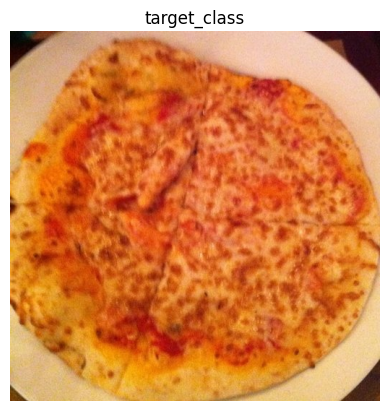

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import tensorflow as tf


# function to plot random images from the directory
def rand_img(target_dir,target_class):
    target_folder=target_dir + target_class # creating a new folder with dir and classes
    random_img=random.sample(os.listdir(target_folder),1)

    img=mpimg.imread(target_folder + "/" +random_img[0]) # loads img as np.array
    plt.imshow(img)
    plt.title("target_class")
    plt.axis("off")

    print("shape:",img.shape)

    return img

img=rand_img(target_dir="pizza_steak/train/",target_class="pizza")
tf.constant(img)


shape: (382, 512, 3)


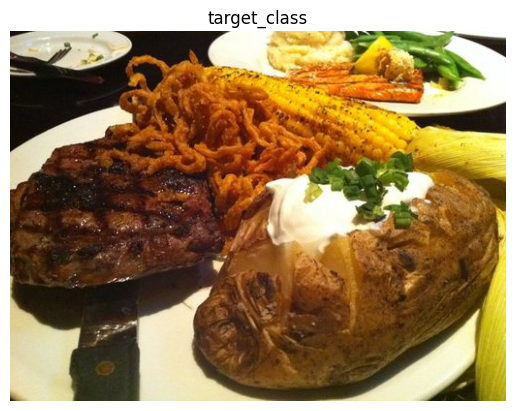

In [16]:
view_rand=rand_img(target_dir="pizza_steak/train/",target_class="steak")

shape: (512, 383, 3)


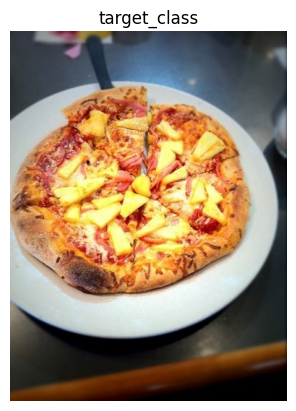

In [17]:
view_rand=rand_img(target_dir="pizza_steak/train/",target_class="pizza")

In [ ]:
# preprocessing the images (Normailsing from 0-255 to 0-1 pixel value range)
# only for 1 random image

img/255.

array([[[0.02352941, 0.04705882, 0.00784314],
        [0.01960784, 0.04313725, 0.00392157],
        [0.02352941, 0.04705882, 0.00784314],
        ...,
        [0.12941176, 0.02745098, 0.07058824],
        [0.1254902 , 0.02352941, 0.05882353],
        [0.1372549 , 0.03529412, 0.07058824]],

       [[0.03137255, 0.05490196, 0.01568627],
        [0.02745098, 0.05098039, 0.01176471],
        [0.03529412, 0.05882353, 0.01960784],
        ...,
        [0.1254902 , 0.02352941, 0.06666667],
        [0.13333333, 0.03137255, 0.06666667],
        [0.15686275, 0.05490196, 0.09019608]],

       [[0.01960784, 0.03921569, 0.01176471],
        [0.02352941, 0.04313725, 0.01568627],
        [0.03137255, 0.05098039, 0.02352941],
        ...,
        [0.10980392, 0.01960784, 0.05098039],
        [0.12941176, 0.02745098, 0.0627451 ],
        [0.15686275, 0.05490196, 0.09019608]],

       ...,

       [[0.45882353, 0.25098039, 0.04705882],
        [0.44313725, 0.23529412, 0.03137255],
        [0.46666667, 0

In [26]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

# normalising all the images 
train_datagen=ImageDataGenerator(rescale=1./255)   # creating instance for rescaling train data
valid_datagen=ImageDataGenerator(rescale=1./255)   # creating instance for rescaling test data

# creating paths
train_dir=r"C:\Users\Dave Roshan\OneDrive\Desktop\CNN_MOD\pizza_steak\train"
test_dir="pizza_steak/test"

# creating image batches from directory
train_data=train_datagen.flow_from_directory(directory=train_dir,batch_size=32,
                                             target_size=(224,224),class_mode="binary",
                                             seed=42)

valid_data=valid_datagen.flow_from_directory(directory=test_dir,batch_size=32,
                                             target_size=(224,224),class_mode="binary",
                                             seed=42)


# CNN MODEL (tiny VGG)
model_l=tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(filters=10,kernel_size=3,activation="relu",input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2,padding="valid"),

    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1,activation="sigmoid") # single O/P neuron for binary classification,sigmoid for 0 or 1 O/P
]) 


# compiling and fit the model

model_l.compile(loss="binary_crossentropy",optimizer=tf.keras.optimizers.Adam(),metrics=["accuracy"])

model_fit=model_l.fit(train_data,epochs=4,steps_per_epoch=len(train_data),
                      validation_data=valid_data,validation_steps=len(valid_data))
print("done")

Found 1500 images belonging to 2 classes.


Found 500 images belonging to 2 classes.
Epoch 1/4
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 430ms/step - accuracy: 0.6940 - loss: 0.5720 - val_accuracy: 0.7400 - val_loss: 0.4996
Epoch 2/4
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.7967 - loss: 0.4525 - val_accuracy: 0.8440 - val_loss: 0.3694
Epoch 3/4
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.8247 - loss: 0.4020 - val_accuracy: 0.8240 - val_loss: 0.3824
Epoch 4/4
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.8247 - loss: 0.3871 - val_accuracy: 0.8580 - val_loss: 0.3555
done


In [28]:
model_l.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

In [ ]:
# HOW THE CNN MODEL WORKS

# Input Image (224×224×3)
#         ↓
# Conv2D  → finds basic features (edges, colors)
# Conv2D  → finds slightly complex features
# MaxPool → shrinks by half
#         ↓
# Conv2D  → finds complex features (shapes)
# Conv2D  → finds more complex features
# MaxPool → shrinks by half again
#         ↓
# Flatten → converts to 1D
#         ↓
# Dense(sigmoid) → outputs probability
#         ↓
#   0.2 → Pizza 
#   0.8 → Steak 